In [25]:
import pandas as pd

In [26]:
df = pd.read_csv('nykaa_top_brands_cosmetics_product_reviews.csv')
print("Dataset: \n Shape:", df.shape, "\n Columns:", df.columns.tolist())

Dataset: 
 Shape: (61284, 18) 
 Columns: ['product_id', 'brand_name', 'review_id', 'review_title', 'review_text', 'author', 'review_date', 'review_rating', 'is_a_buyer', 'pro_user', 'review_label', 'product_title', 'mrp', 'price', 'product_rating', 'product_rating_count', 'product_tags', 'product_url']


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61284 entries, 0 to 61283
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            61284 non-null  int64  
 1   brand_name            61284 non-null  object 
 2   review_id             61284 non-null  int64  
 3   review_title          61284 non-null  object 
 4   review_text           61275 non-null  object 
 5   author                61284 non-null  object 
 6   review_date           61284 non-null  object 
 7   review_rating         61283 non-null  float64
 8   is_a_buyer            61284 non-null  bool   
 9   pro_user              61284 non-null  bool   
 10  review_label          48249 non-null  object 
 11  product_title         61284 non-null  object 
 12  mrp                   61284 non-null  int64  
 13  price                 61284 non-null  int64  
 14  product_rating        61284 non-null  float64
 15  product_rating_coun

In [28]:
df.isnull().sum()

product_id                  0
brand_name                  0
review_id                   0
review_title                0
review_text                 9
author                      0
review_date                 0
review_rating               1
is_a_buyer                  0
pro_user                    0
review_label            13035
product_title               0
mrp                         0
price                       0
product_rating              0
product_rating_count        0
product_tags            47782
product_url                 0
dtype: int64

In [29]:
df.head()

,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,pro_user,review_label,product_title,mrp,price,product_rating,product_rating_count,product_tags,product_url
0,781070,Olay,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,2021-01-23 15:17:18,5.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,781070,Olay,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,2020-09-07 15:30:42,5.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,781070,Olay,15618995,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,2020-11-13 12:24:14,4.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
3,781070,Olay,13474509,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,2020-06-14 11:56:50,3.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
4,781070,Olay,16338982,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,2020-12-22 15:24:35,2.0,True,False,Verified Buyer,Olay Ultra Lightweight Moisturiser: Luminous W...,1999,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


In [30]:
# convert review_date from text to datetime format
df['review_date'] = pd.to_datetime(df['review_date'])

print(df['review_date'].dtype)
print(df['review_date'].head(3))

datetime64[ns]
0   2021-01-23 15:17:18
1   2020-09-07 15:30:42
2   2020-11-13 12:24:14
Name: review_date, dtype: datetime64[ns]


In [31]:
# fill missing values with meaningful labels
df['review_label'] = df['review_label'].fillna('Unverified Buyer')
df['product_tags'] = df['product_tags'].fillna('No Tags')

print(df[['product_tags', 'review_label']].isnull().sum())

product_tags    0
review_label    0
dtype: int64


In [32]:
# Extract year, month, month name from review_data column
df['year'] = df['review_date'].dt.year
df['month'] = df['review_date'].dt.month
df['month_name'] = df['review_date'].dt.strftime('%b')

print(df[['year', 'month', 'month_name', 'review_date']].head())

   year  month month_name         review_date
0  2021      1        Jan 2021-01-23 15:17:18
1  2020      9        Sep 2020-09-07 15:30:42
2  2020     11        Nov 2020-11-13 12:24:14
3  2020      6        Jun 2020-06-14 11:56:50
4  2020     12        Dec 2020-12-22 15:24:35


In [33]:
# calculate discount percentage - how much off from MRP?
df['discount_pct'] = ((df['mrp'] - df['price']) / df['mrp'] * 100).round(1)

print(df[['mrp', 'price', 'discount_pct']].head())
print("\nAverage discount across all products: ", df['discount_pct'].mean().round(1), '%')

    mrp  price  discount_pct
0  1999   1599          20.0
1  1999   1599          20.0
2  1999   1599          20.0
3  1999   1599          20.0
4  1999   1599          20.0

Average discount across all products:  17.7 %


In [34]:
from pandasql import sqldf
pysql = lambda q: sqldf(q, {'df': df})

In [35]:
# How many reviews does each brand have?
results = pysql("""
    SELECT
    brand_name,
    COUNT(*) AS total_reviews
    FROM df
    GROUP BY brand_name
    ORDER BY total_reviews DESC
""")
print(results)

                 brand_name  total_reviews
0           Nykaa Cosmetics          17652
1                Kay Beauty          13788
2                     Lakme           6999
3       Maybelline New York           6821
4           Herbal Essences           6197
5             L'Oreal Paris           4273
6   NYX Professional Makeup           2954
7            Nykaa Naturals           1426
8                     Nivea            774
9                      Olay            399
10                 Colorbar              1


In [36]:
# Which brand gets best reviews on average?
result2 = pysql("""
    SELECT 
        brand_name,
        ROUND(AVG(review_rating), 2) AS avg_rating,
        COUNT(*) AS total_reviews
    FROM df
    WHERE brand_name != 'Colorbar'
    GROUP BY brand_name
    ORDER BY avg_rating DESC
""")

print(result2)

                brand_name  avg_rating  total_reviews
0               Kay Beauty        4.70          13788
1          Nykaa Cosmetics        4.46          17652
2          Herbal Essences        4.33           6197
3      Maybelline New York        4.28           6821
4                    Lakme        4.28           6999
5  NYX Professional Makeup        4.27           2954
6            L'Oreal Paris        4.19           4273
7           Nykaa Naturals        4.13           1426
8                    Nivea        3.97            774
9                     Olay        3.83            399


In [37]:
# Which Year had the most reviews per brand?
result3 = pysql("""
    SELECT
        brand_name,
        year,
        COUNT(*) AS review
    FROM df
    WHERE year >= 2019
    GROUP BY brand_name, year
    ORDER BY brand_name, year
""")

print(result3)

                 brand_name  year  review
0                  Colorbar  2022       1
1           Herbal Essences  2019    1858
2           Herbal Essences  2020    1763
3           Herbal Essences  2021    1998
4           Herbal Essences  2022     578
5                Kay Beauty  2019     100
6                Kay Beauty  2020    3690
7                Kay Beauty  2021    5810
8                Kay Beauty  2022    4188
9             L'Oreal Paris  2019    1061
10            L'Oreal Paris  2020    1111
11            L'Oreal Paris  2021     783
12            L'Oreal Paris  2022     453
13                    Lakme  2019    1485
14                    Lakme  2020    1575
15                    Lakme  2021    1259
16                    Lakme  2022     529
17      Maybelline New York  2019    2389
18      Maybelline New York  2020    1673
19      Maybelline New York  2021     957
20      Maybelline New York  2022     322
21  NYX Professional Makeup  2019     892
22  NYX Professional Makeup  2020 

In [38]:
# How many verified buyers gave 5 stars
result4 = pysql("""
    SELECT
        brand_name,
        COUNT(*) AS five_star_verified
    FROM df
    WHERE review_rating = 5 AND review_label = 'Verified Buyer'
    GROUP BY brand_name
    ORDER BY five_star_verified DESC
""")

print(result4)

                brand_name  five_star_verified
0          Nykaa Cosmetics               11613
1               Kay Beauty                9551
2      Maybelline New York                3213
3          Herbal Essences                2672
4                    Lakme                2416
5            L'Oreal Paris                1700
6  NYX Professional Makeup                1147
7           Nykaa Naturals                 498
8                    Nivea                 268
9                     Olay                 100


In [39]:
# Do discounted products get best or worst reviews?
result5 = pysql("""
    SELECT 
        CASE
            WHEN discount_pct = 0 THEN 'No discount'
            WHEN discount_pct <= 10 THEN 'Low (1-10%)'
            WHEN discount_pct <= 25 THEN 'Medium (11-25%)'
            ELSE 'High (25% +)'
        END AS discount_bucket,
        COUNT(*) AS reviews,
        ROUND(AVG(review_rating), 2) AS avg_rating
    FROM df
    GROUP BY discount_bucket
    ORDER BY avg_rating DESC
""")

print(result5)

   discount_bucket  reviews  avg_rating
0  Medium (11-25%)    29477        4.54
1     High (25% +)    12483        4.39
2      No discount    17437        4.24
3      Low (1-10%)     1887        4.24


In [40]:
# Which brand has five star Ratio
result6 = pysql("""
    SELECT
        brand_name,
        COUNT(*) AS total_reviews,
        SUM(CASE WHEN review_rating = 5 THEN 1 ELSE 0 END) AS five_star_count,
        ROUND(100.0 * SUM(CASE WHEN review_rating = 5 THEN 1 ELSE 0 END) / COUNT(*), 1) AS five_star_pct
    FROM df
    WHERE brand_name != 'Colorbar'
    GROUP BY brand_name
    ORDER BY five_star_pct DESC
""")

print(result6)

                brand_name  total_reviews  five_star_count  five_star_pct
0               Kay Beauty          13788            11244           81.5
1          Nykaa Cosmetics          17652            12941           73.3
2          Herbal Essences           6197             4121           66.5
3      Maybelline New York           6821             4025           59.0
4  NYX Professional Makeup           2954             1702           57.6
5            L'Oreal Paris           4273             2406           56.3
6                    Lakme           6999             3904           55.8
7           Nykaa Naturals           1426              722           50.6
8                    Nivea            774              372           48.1
9                     Olay            399              189           47.4


**INSIGHT**
- Kay Beauty has the highest 5-star review ratio among all 11 brands on Nykaa, suggesting stronger customer satisfaction relative to review volume compared to Nykaa Cosmetics which leads only in raw count.

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'whitegrid')

%matplotlib inline

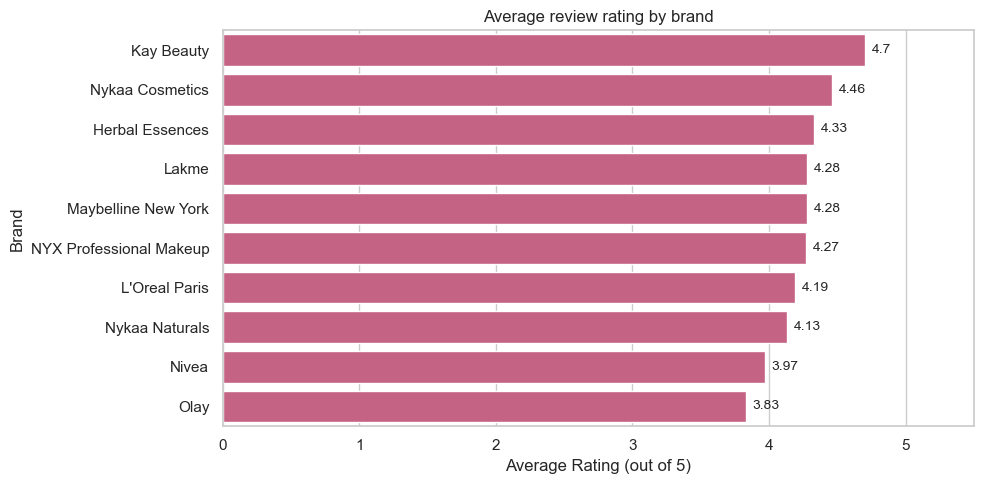

In [42]:
# Average review rating by brand
brand_rating = (df[df['brand_name'] != 'Colorbar']
               .groupby('brand_name')['review_rating']
               .mean()
               .round(2)
               .sort_values(ascending = False)
               .reset_index())
brand_rating.columns = ['brand_name', 'avg_rating']

fig, ax = plt.subplots(figsize = (10,5))

sns.barplot(data = brand_rating,
           x = 'avg_rating',
           y = 'brand_name',
           color = '#D4537E')

ax.set_title("Average review rating by brand")
ax.set_xlabel('Average Rating (out of 5)')
ax.set_ylabel('Brand')
ax.set_xlim(0, 5.5)

for i, v in enumerate(brand_rating['avg_rating']):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart1_brand_ratings.png', dpi=150)
plt.show()

**Insight**
- Kay Beauty consistently outperformed all other Nykaa Brands on customer satisfaction, while massive brands like Olay and Nivea score lowest - suggesting permium beauty brands drive stronger loyalty

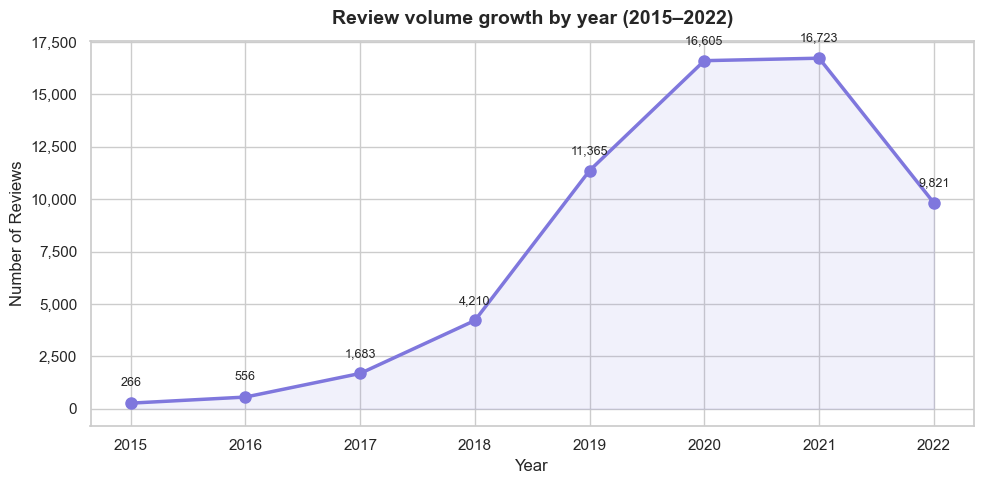

In [43]:
# Review volume by year — how has engagement grown?
yearly = (df[df['year'] >= 2015]
          .groupby('year')['review_id']
          .count()
          .reset_index())
yearly.columns = ['year', 'total_reviews']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly['year'], yearly['total_reviews'], 
        color='#7F77DD', linewidth=2.5, 
        marker='o', markersize=8)

ax.fill_between(yearly['year'], yearly['total_reviews'], 
                alpha=0.1, color='#7F77DD')

for _, row in yearly.iterrows():
    ax.annotate(f"{int(row['total_reviews']):,}",
                xy=(row['year'], row['total_reviews']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_title('Review volume growth by year (2015–2022)', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(yearly['year'])

plt.tight_layout()
plt.savefig('chart2_yearly_trend.png', dpi=150)
plt.show()

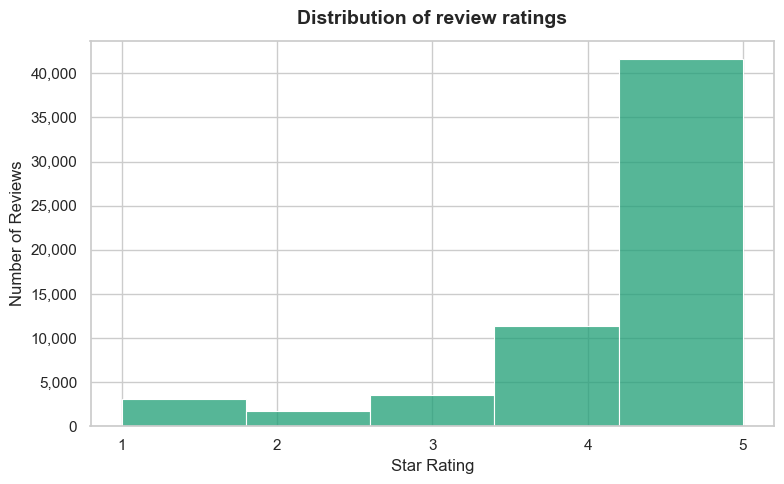

In [44]:
# Distribution of all review ratings
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(data=df, x='review_rating', 
             bins=5, color='#1D9E75',
             edgecolor='white', linewidth=0.8)

ax.set_title('Distribution of review ratings', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_xticks([1, 2, 3, 4, 5])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('chart3_rating_distribution.png', dpi=150)
plt.show()

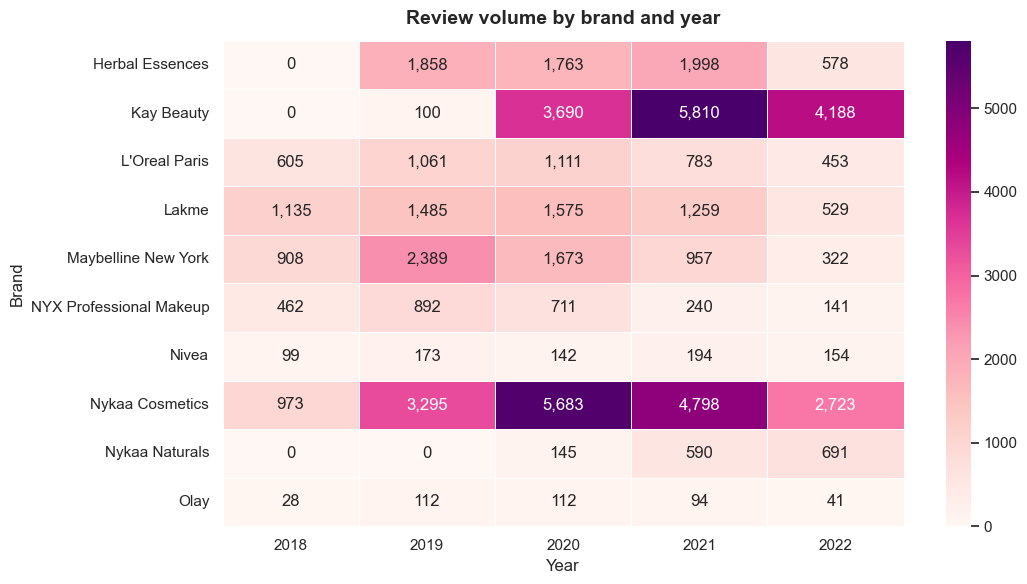

In [45]:
# Heatmap — brand vs year review volume
heatmap_data = (df[df['year'] >= 2018]
               .groupby(['brand_name', 'year'])['review_id']
               .count()
               .unstack(fill_value = 0))
heatmap_data = heatmap_data.drop('Colorbar', errors='ignore')

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(heatmap_data,
            annot=True,           
            fmt=',',              
            cmap='RdPu',          
            linewidths=0.5,
            linecolor='white',
            ax=ax)

ax.set_title('Review volume by brand and year', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Brand')

plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150)
plt.show()

C:\Users\FLORENCIA ABEL\AppData\Local\Temp\ipykernel_15900\1063536815.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['brand_name'] != 'Colorbar'],


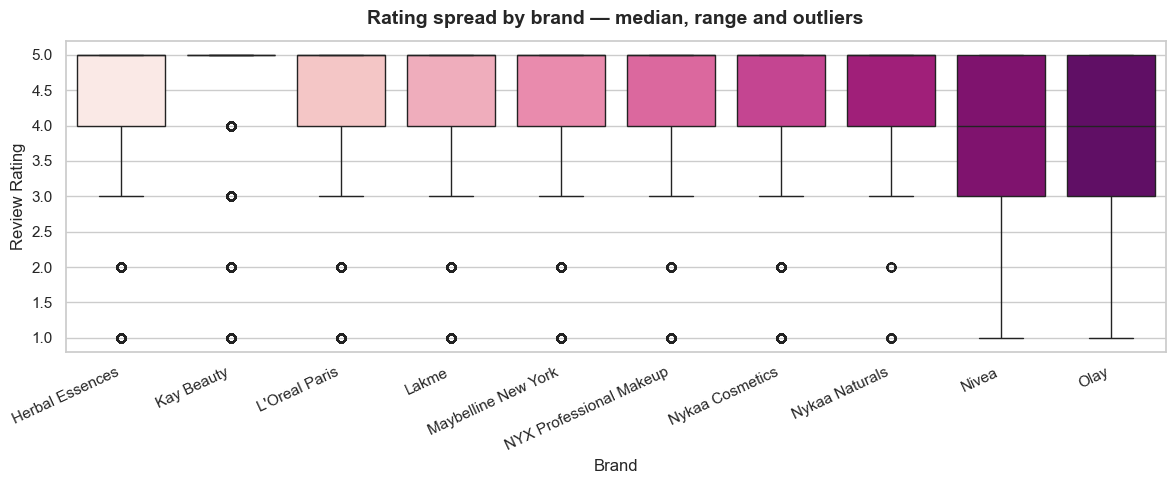

In [46]:
#Box plot — rating spread per brand
fig, ax = plt.subplots(figsize=(12, 5))

order = (df[df['brand_name'] != 'Colorbar']
         .groupby('brand_name')['review_rating']
         .median()
         .sort_values(ascending=False)
         .index)

sns.boxplot(data=df[df['brand_name'] != 'Colorbar'],
            x='brand_name',
            y='review_rating',
            order=order,
            palette='RdPu')

ax.set_title('Rating spread by brand — median, range and outliers',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Brand')
ax.set_ylabel('Review Rating')
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.savefig('chart5_boxplot.png', dpi=150)
plt.show()

**Insights**
- Kay Beauty leads in avg rating and 5-star ratio
- Reviews tripled in 2019, peaked in 2021
- Ratings are right skewed
- Kay Beauty dominated 2021 with 5,810 reviews
- Nivea and Olay most inconsistent ratings
- Medium discounts drive more reviews than high discounts

In [47]:
# Export cleaned data for Power BI
export_cols = ['brand_name', 'product_title', 'review_title', 
               'review_text', 'review_rating', 'review_date',
               'year', 'month', 'month_name', 'mrp', 'price',
               'discount_pct', 'review_label', 'product_tags']

df[export_cols].to_excel('nykaa_cleaned.xlsx', index=False)
print(f"Exported {len(df):,} rows to nykaa_cleaned.xlsx")

Exported 61,284 rows to nykaa_cleaned.xlsx


In [48]:
# Check what got exported
import pandas as pd
check = pd.read_excel('nykaa_cleaned.xlsx')
print("Rows:", len(check))
print("Columns:", check.columns.tolist())
print("\nData types:")
print(check.dtypes)

Rows: 61284
Columns: ['brand_name', 'product_title', 'review_title', 'review_text', 'review_rating', 'review_date', 'year', 'month', 'month_name', 'mrp', 'price', 'discount_pct', 'review_label', 'product_tags']

Data types:
brand_name               object
product_title            object
review_title             object
review_text              object
review_rating           float64
review_date      datetime64[ns]
year                      int64
month                     int64
month_name               object
mrp                       int64
price                     int64
discount_pct            float64
review_label             object
product_tags             object
dtype: object
